In [1]:
import jax 
import gpjax as gpx
import jax.numpy as jnp
from jax import config
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import install_import_hook
import matplotlib as mpl
import matplotlib.pyplot as plt
import optax
from core.model import SparseHyperelasticityGP
from core.material_models import get_material
import jax
import jax.numpy as jnp
from core.utils import *
import datetime
import os

from core.datasetclass import TractionDataset
from core.loss_function import physical_loss, elbo_loss

dataset = TractionDataset("dataset","Isihara")

# Initialize empty lists to store data from all steps
all_F = []

# for i in range(len(dataset)):
#     data = dataset[i]
#     coords = data["mesh_pos"][:,:2]
#     cells = data["cells"]
#     u = data["u"]
#     u = u + jax.random.normal(jr.key(0), u.shape) * noise * jnp.std(u)
#     node_type = data["node_type"]
#     load_parameter = data["load_parameter"]

#     coord_cells = coords[cells]
#     u_cells = u[cells]

#     F, dNdx = deformation_gradient_element(coord_cells, u_cells)
#     # all_F.append(F)
#     if (i == len(dataset) - 1):
#         all_F.append(F)
    # break

    
base_save_path = "saved_model"  # change as needed
os.makedirs(base_save_path, exist_ok=True)

noise_levels = [0.0, 0.0001, 0.001, 0.01] # Different noise levels to analyze

# fig_combined, axes_combined = plt.subplots(len(noise_levels), 3, figsize=(22, 6 * len(noise_levels)))

for row_idx, noise in enumerate(noise_levels):
    name = f"analysis1_with_noise{noise:.3f}"
    save_path = os.path.join(base_save_path, name)
    os.makedirs(save_path, exist_ok=True)

    all_F = []
    for i in range(len(dataset)):
        data = dataset[i]
        coords = data["mesh_pos"][:,:2]
        cells = data["cells"]
        u = data["u"]
        # Apply noise based on the current noise level
        u = u + jax.random.normal(jr.key(0), u.shape) * noise * jnp.std(u)
        node_type = data["node_type"]
        load_parameter = data["load_parameter"]

        coord_cells = coords[cells]
        u_cells = u[cells]

        F, dNdx = deformation_gradient_element(coord_cells, u_cells)
        # if (i == len(dataset) - 1):
        all_F.append(F)

In [3]:
F = jnp.concatenate(all_F, axis=0) # Concatenate all F tensors

I_obs, _ = jax.vmap(invariants_and_derivatives)(F)
f = jax.vmap(fto3x3)(F)
psi = jax.vmap(get_material("isihara").phi)(f)

from sklearn.cluster import KMeans

x = I_obs[:, 0] * I_obs[:, 2]**(-1/3)
y = I_obs[:, 1] * I_obs[:, 2]**(-2/3)
z = (I_obs[:, 2] ** (1/2) - 1)**2

I_obs_dev = jnp.stack([x,y,z], axis = -1)

In [5]:
I_obs

Array([[ 3.40265734,  3.84464435,  1.441987  ],
       [ 3.43493426,  3.91576016,  1.4808259 ],
       [ 3.47155125,  3.99626526,  1.52471402],
       ...,
       [ 5.98108418,  9.23047185,  4.24938767],
       [ 7.90991327, 11.34021485,  4.43030158],
       [ 6.51058908,  9.81900994,  4.30842086]], dtype=float64)

In [4]:
I_obs_dev

Array([[3.01183448, 3.01218707, 0.04033174],
       [3.0135872 , 3.0140243 , 0.0470421 ],
       [3.0162045 , 3.01667631, 0.0551278 ],
       ...,
       [3.69264703, 3.51835507, 1.12657908],
       [4.81608295, 4.20402951, 1.22064526],
       [4.00111387, 3.70842033, 1.15707368]], dtype=float64)

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Prepare your data (assuming df contains your I1 and I2 values)
# PCA is sensitive to scale, so we use the raw invariant values.
X = I_obs_dev[:, :2]

# 2. Standardize the data 
# This ensures both invariants contribute equally to the variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA
pca = PCA(n_components=1)  # We only want the first principal component
pc1 = pca.fit_transform(X_scaled)

# # 5. Plot Psi vs PC1
# plt.figure(figsize=(10, 6))
# plt.scatter(df['PC1'], df['Psi'], c=df['Psi'], cmap='viridis', alpha=0.7)
# plt.xlabel('Principal Component 1 (Direction of Max Variance)')
# plt.ylabel('Strain Energy ($\Psi$)')
# plt.title('Energy Landscape along the Main Deformation Path')
# plt.colorbar(label='$\Psi$')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

# # Optional: Check how much information we kept
# print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0] * 100:.2f}%")

In [23]:
%matplotlib widget 

RuntimeError: 'widget' is not a recognised GUI loop or backend name

In [ ]:
# For JupyterLab / Jupyter Notebook (requires 'ipympl' to be installed)


# OR, for older Jupyter Notebooks
# %matplotlib notebook 

import matplotlib.pyplot as plt
# ... (rest of your code)

RuntimeError: 'widget' is not a recognised GUI loop or backend name

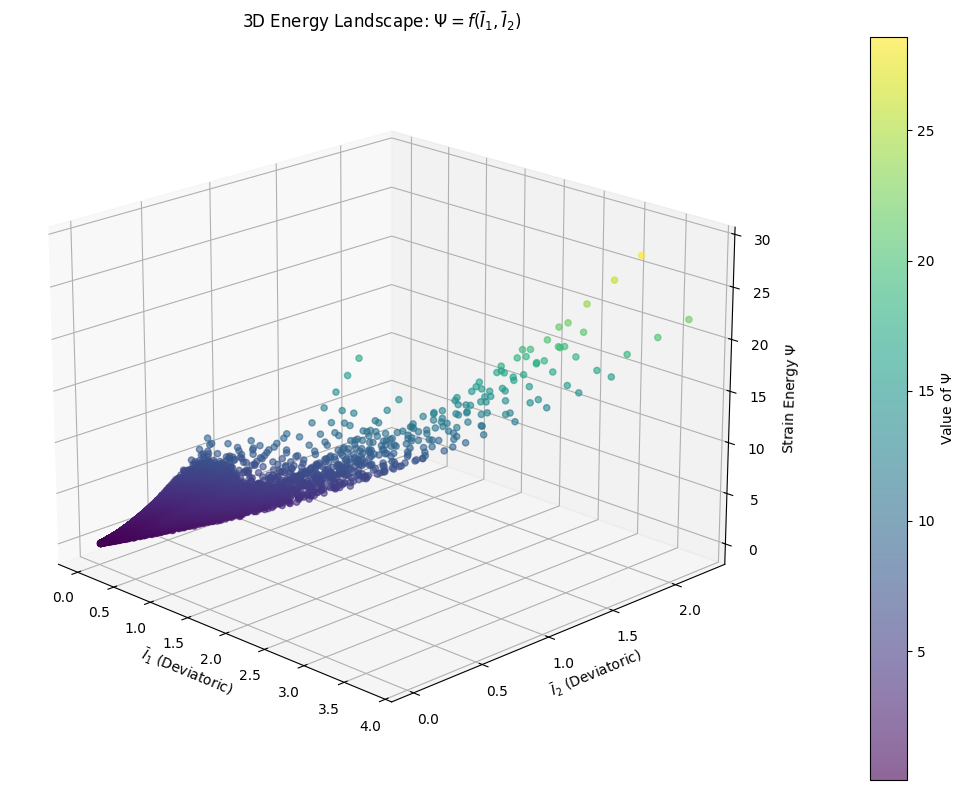

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 1. Setup the figure and 3D axis
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 2. Extract data from your dataframe
# Assuming df contains 'I1_bar', 'I2_bar', and 'Psi'
x = I_obs_dev[:, 0] - 3
y = I_obs_dev[:, 1] - 3
z = psi

# 3. Create the 3D scatter plot
# We color the points by Psi (z) to make the energy gradients clearer
scatter = ax.scatter(x, y, z, c=z, cmap='viridis', s=20, alpha=0.6)

# 4. Set labels using LaTeX formatting
ax.set_xlabel(r'$\bar{I}_1$ (Deviatoric)')
ax.set_ylabel(r'$\bar{I}_2$ (Deviatoric)')
ax.set_zlabel(r'Strain Energy $\Psi$')
ax.set_title(r'3D Energy Landscape: $\Psi = f(\bar{I}_1, \bar{I}_2)$')

# 5. Add a colorbar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label(r'Value of $\Psi$')

# 6. Adjust the viewing angle (optional)
# This angle often helps visualize the "climb" of the energy curve
ax.view_init(elev=20, azim=-45)

plt.tight_layout()
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:6: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:6: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_3676/1298089797.py:4: SyntaxWarning: invalid escape sequence '\P'
  plt.ylabel('Strain Energy ($\Psi$)')
/tmp/ipykernel_3676/1298089797.py:6: SyntaxWarning: invalid escape sequence '\P'
  plt.colorbar(label='$\Psi$')
/tmp/ipykernel_3676/1298089797.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(I_obs_dev[:, 1], psi, cmap='viridis', alpha=0.7)


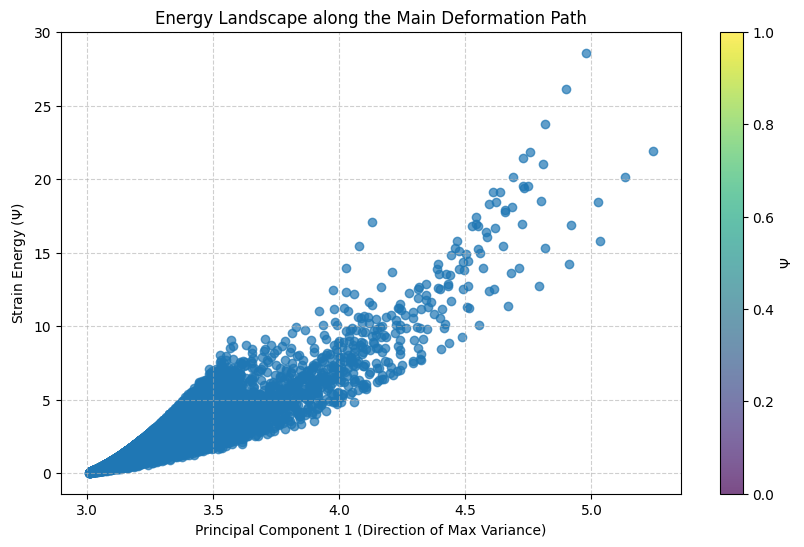

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(I_obs_dev[:, 1], psi, cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1 (Direction of Max Variance)')
plt.ylabel('Strain Energy ($\Psi$)')
plt.title('Energy Landscape along the Main Deformation Path')
plt.colorbar(label='$\Psi$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [1]:
import jax.numpy as jnp
import pandas as pd
import jax
import jax.numpy as jnp
import jax.random as jr
from core.material_models import get_material
from core.utils import *
from core.datasetclass import TractionDataset
from core.model import SparseHyperelasticityGP
import os
import matplotlib.pyplot as plt

In [2]:
# 3. Data Processing (Re-runs when slider moves)
def load_base_dataset():
    return TractionDataset("dataset", "Isihara")

dataset = load_base_dataset()
all_F = []

# Process the dataset with the selected noise
for i in range(len(dataset)):
    data = dataset[i]
    coords = data["mesh_pos"][:, :2]
    cells = data["cells"]
    u = data["u"]
    
    # Apply noise from slider
    u_noisy = u + jax.random.normal(jr.key(0), u.shape) * 0.0 * jnp.std(u)
    
    coord_cells = coords[cells]
    u_cells = u_noisy[cells]

    # Calculate deformation gradient
    F_el, _ = deformation_gradient_element(coord_cells, u_cells)
    
    # Only taking the last snapshot as per your original logic
    if (i == len(dataset) - 1):
        all_F.append(F_el)  

F_total = jnp.concatenate(all_F, axis=0)
I_obs, _ = jax.vmap(invariants_and_derivatives)(F_total)

In [3]:
model_path = "/home/mmdiscovery/shared/saved_model/20260101T182904/" # Replace with the actual path to your saved model
with open(os.path.join(model_path, "best_params.npy"), "rb") as f:
    best_params = jnp.load(f, allow_pickle=True).item()

with open(os.path.join(model_path, "Z_stacked.npy"), "rb") as f:
    Z_stacked = jnp.load(f, allow_pickle=True)

In [4]:
print(best_params)

{'inducing_latent_variable_mean': Array([1.46742212, 5.84081264, 3.02292637], dtype=float64), 'log_growth_constant': Array(0.43855918, dtype=float64), 'log_inducing_latent_variable_var': Array([-5.94948326, -6.05441612, -6.13509548], dtype=float64), 'log_lengthscales': Array([-1.45649743,  0.68555056], dtype=float64), 'offset': Array(1.42121785, dtype=float64), 'poly_degree': Array(2.84142422, dtype=float64), 'sigma_physic': Array(0.00357034, dtype=float64), 'sigma_poly': Array(0.05486132, dtype=float64), 'sigma_scaling': Array(-0.04425035, dtype=float64)}


In [5]:
learned_gp = SparseHyperelasticityGP(best_params, Z_stacked)
true_model = get_material("isihara")

In [6]:
num_points = 100
gamma_range = (1.0, 2.0)
gamma = jnp.linspace(gamma_range[0], gamma_range[1], num_points)

# Uniaxial Tension
f_ut = jnp.zeros((num_points, 3, 3))
f_ut = f_ut.at[:,0,0].set(gamma)
f_ut = f_ut.at[:,1,1].set(1)
f_ut = f_ut.at[:,2,2].set(1)

In [7]:
psi_pred_func = jax.jit(jax.vmap(learned_gp.psi, in_axes=(0, None)))

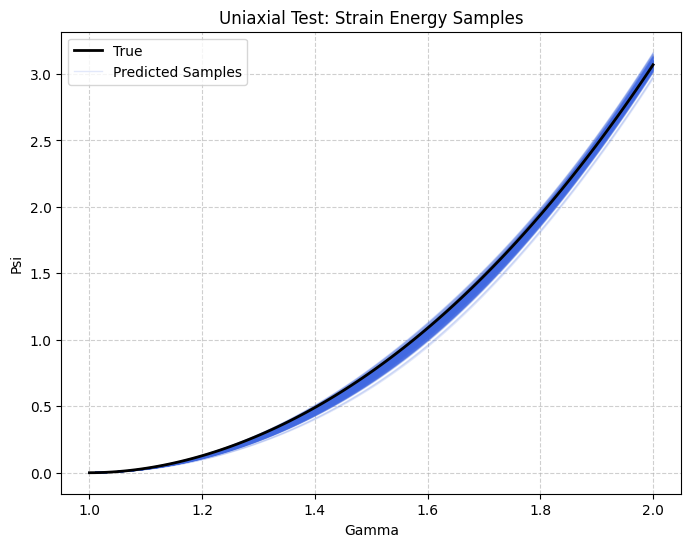

In [9]:
num_points = 100
gamma_range = (1.0, 2.0)
gamma = jnp.linspace(gamma_range[0], gamma_range[1], num_points)

# Uniaxial Tension
f_ut = jnp.zeros((num_points, 3, 3))
f_ut = f_ut.at[:,0,0].set(gamma)
f_ut = f_ut.at[:,1,1].set(1)
f_ut = f_ut.at[:,2,2].set(1)
psi_true = true_model.phi(f_ut)
plt.figure(figsize=(8, 6))
plt.plot(gamma, psi_true, label="True", color="black", linewidth=2, zorder=3)

# Plot samples with low opacity
for i in range(200):
    # Pass a new key for each sample to ensure stochasticity
    psi_pred = psi_pred_func(f_ut, jr.PRNGKey(i))
    
    # Use alpha for transparency and set label only for the first iteration
    label = "Predicted Samples" if i == 0 else None
    plt.plot(gamma, psi_pred, color="royalblue", alpha=0.15, label=label, linewidth=1)

plt.xlabel("Gamma")
plt.ylabel("Psi")
plt.title("Uniaxial Test: Strain Energy Samples")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [107]:
psi_pred = psi_pred_func(f_ut, jr.PRNGKey(i))

In [72]:
psi_pred

Array([0.00000000e+00, 7.89942229e-02, 3.41773612e-01, 8.23053760e-01,
       1.56731218e+00, 2.63213132e+00, 4.07478440e+00, 5.93384677e+00,
       8.22877963e+00, 1.09755783e+01, 1.41967795e+01, 1.79207647e+01,
       2.21778566e+01, 2.69949382e+01, 3.23867625e+01, 3.83814967e+01,
       4.50161980e+01, 5.23226428e+01, 6.03312366e+01, 6.90721082e+01,
       7.85753283e+01, 8.88709681e+01, 9.99891183e+01, 1.11959897e+02,
       1.24813452e+02, 1.38579965e+02, 1.53289648e+02, 1.68972747e+02,
       1.85659541e+02, 2.03380344e+02, 2.22165501e+02, 2.42045392e+02,
       2.63050430e+02, 2.85211060e+02, 3.08557762e+02, 3.33121048e+02,
       3.58931463e+02, 3.86019585e+02, 4.14416025e+02, 4.44151425e+02,
       4.75256461e+02, 5.07761840e+02, 5.41698301e+02, 5.77096616e+02,
       6.13987586e+02, 6.52402045e+02, 6.92370858e+02, 7.33924920e+02,
       7.77095159e+02, 8.21912530e+02,            inf,            inf,
                  inf,            inf,            inf,            inf,
      

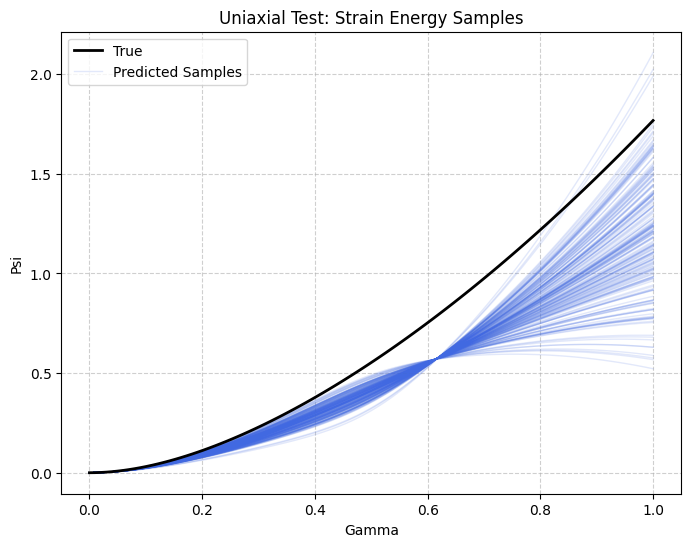

In [10]:
num_points = 100
gamma_range = (0.0, 1.0)
gamma = jnp.linspace(gamma_range[0], gamma_range[1], num_points)

# Uniaxial Tension
f_ps = jnp.zeros((num_points, 3, 3))
f_ps = f_ps.at[:,0,0].set(1/(1+gamma))
f_ps = f_ps.at[:,1,1].set(1)
f_ps = f_ps.at[:,2,2].set(1)
psi_true = true_model.phi(f_ps)
plt.figure(figsize=(8, 6))
plt.plot(gamma, psi_true, label="True", color="black", linewidth=2, zorder=3)

# Plot samples with low opacity
for i in range(200):
    # Pass a new key for each sample to ensure stochasticity
    psi_pred = psi_pred_func(f_ps, jr.PRNGKey(i))
    
    # Use alpha for transparency and set label only for the first iteration
    label = "Predicted Samples" if i == 0 else None
    plt.plot(gamma, psi_pred, color="royalblue", alpha=0.15, label=label, linewidth=1)

plt.xlabel("Gamma")
plt.ylabel("Psi")
plt.title("Uniaxial Test: Strain Energy Samples")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

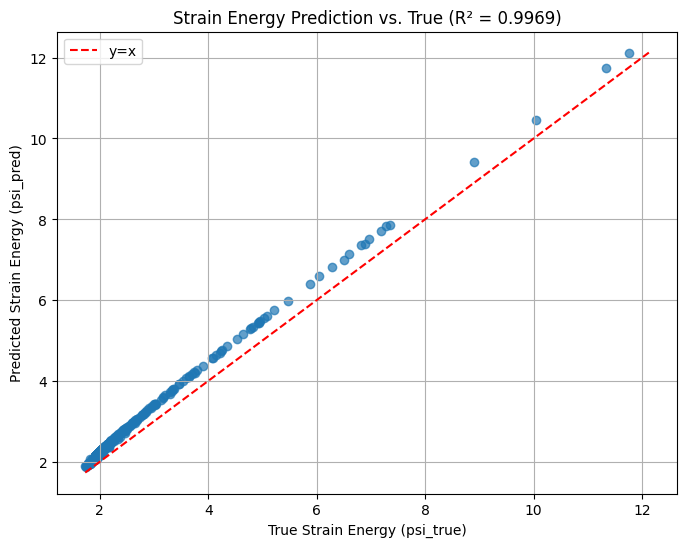

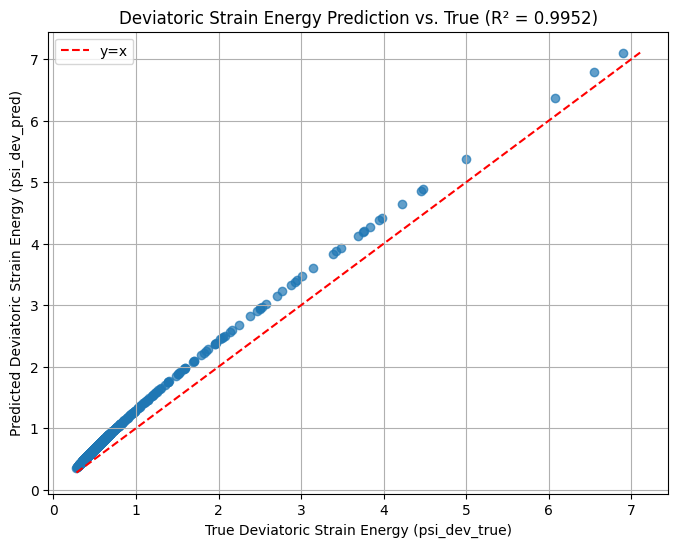

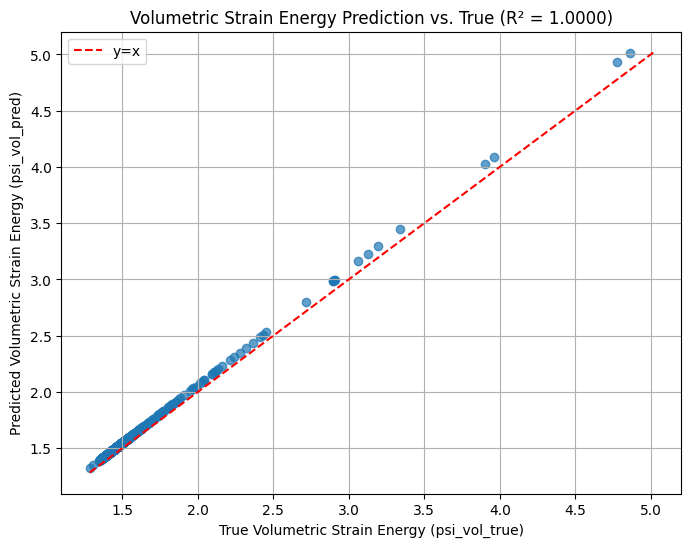

In [36]:

learned_gp = SparseHyperelasticityGP(best_params["lengthscales"], best_params["log_scale_variance"], best_params["log_sigma_poly"], best_params["log_offset"], best_params["log_growth_constant"], best_params["poly_degree"],best_params["g_mean"], Z_stacked)
F = F_total
f = jax.vmap(fto3x3)(F)
psi_pred = jax.vmap(learned_gp.psi)(f)
psi_dev_pred = psi_pred - jax.vmap(learned_gp.psi_vol_gp)(I_obs)
psi_vol_pred = jax.vmap(learned_gp.psi_vol_gp)(I_obs)

true_model = get_material("isihara")
psi_true = true_model.phi(f)
psi_dev_true = psi_true - 1.5 * (jnp.sqrt(I_obs[:, 2]) - 1)**2
psi_vol_true = 1.5 * (jnp.sqrt(I_obs[:, 2]) - 1)**2


# Plot R2 between psi_pred and psi_true
plt.figure(figsize=(8, 6))

# Flatten the arrays for plotting and R2 calculation
psi_pred_flat = psi_pred.flatten()
psi_true_flat = psi_true.flatten()



# Calculate R2 score
r2 = jnp.corrcoef(psi_true_flat, psi_pred_flat)[0, 1]**2

plt.scatter(psi_true_flat, psi_pred_flat, alpha=0.7)

# Add a 45-degree line
min_val = min(psi_true_flat.min(), psi_pred_flat.min())
max_val = max(psi_true_flat.max(), psi_pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='y=x')

plt.xlabel("True Strain Energy (psi_true)")
plt.ylabel("Predicted Strain Energy (psi_pred)")
plt.title(f"Strain Energy Prediction vs. True (R² = {r2:.4f})")
plt.legend()
plt.grid(True)
plt.show()

# # Plot R2 between psi_dev_pred and psi_dev_true
plt.figure(figsize=(8, 6))

# Flatten the arrays for plotting and R2 calculation
psi_dev_pred_flat = psi_dev_pred.flatten()
psi_dev_true_flat = psi_dev_true.flatten()

# Calculate R2 score
r2_dev = jnp.corrcoef(psi_dev_true_flat, psi_dev_pred_flat)[0, 1]**2

plt.scatter(psi_dev_true_flat, psi_dev_pred_flat, alpha=0.7)

# Add a 45-degree line
min_val_dev = min(psi_dev_true_flat.min(), psi_dev_pred_flat.min())
max_val_dev = max(psi_dev_true_flat.max(), psi_dev_pred_flat.max())
plt.plot([min_val_dev, max_val_dev], [min_val_dev, max_val_dev], color='red', linestyle='--', label='y=x')

plt.xlabel("True Deviatoric Strain Energy (psi_dev_true)")
plt.ylabel("Predicted Deviatoric Strain Energy (psi_dev_pred)")
plt.title(f"Deviatoric Strain Energy Prediction vs. True (R² = {r2_dev:.4f})")
plt.legend()
plt.grid(True)
plt.show()

# Plot R2 between psi_vol_pred and psi_vol_true
plt.figure(figsize=(8, 6))

# Flatten the arrays for plotting and R2 calculation
psi_vol_pred_flat = psi_vol_pred.flatten()
psi_vol_true_flat = psi_vol_true.flatten()

# Calculate R2 score
r2_vol = jnp.corrcoef(psi_vol_true_flat, psi_vol_pred_flat)[0, 1]**2

plt.scatter(psi_vol_true_flat, psi_vol_pred_flat, alpha=0.7)

# Add a 45-degree line
min_val_vol = min(psi_vol_true_flat.min(), psi_vol_pred_flat.min())
max_val_vol = max(psi_vol_true_flat.max(), psi_vol_pred_flat.max())
plt.plot([min_val_vol, max_val_vol], [min_val_vol, max_val_vol], color='red', linestyle='--', label='y=x')

plt.xlabel("True Volumetric Strain Energy (psi_vol_true)")
plt.ylabel("Predicted Volumetric Strain Energy (psi_vol_pred)")
plt.title(f"Volumetric Strain Energy Prediction vs. True (R² = {r2_vol:.4f})")
plt.legend()
plt.grid(True)
plt.show()

# --- Deformation Modes Plots ---
num_points = 100
gamma_range = (1.0, 4.0)
gamma = jnp.linspace(gamma_range[0], gamma_range[1], num_points)

# Uniaxial Tension
f_ut = jnp.zeros((num_points, 3, 3))
f_ut = f_ut.at[:,0,0].set(gamma)
f_ut = f_ut.at[:,1,1].set(1)
f_ut = f_ut.at[:,2,2].set(1)

# Equibiaxial Tension
f_ebt = jnp.zeros((num_points, 3, 3))
f_ebt = f_ebt.at[:,0,0].set(gamma)
f_ebt = f_ebt.at[:,1,1].set(gamma)
f_ebt = f_ebt.at[:,2,2].set(1)

# Pure Shear
f_ps = jnp.zeros((num_points, 3, 3))
f_ps = f_ps.at[:,0,0].set(gamma)
f_ps = f_ps.at[:,1,1].set(1/gamma)
f_ps = f_ps.at[:,2,2].set(1)

# Uniaxial Compression (using gamma < 1)
gamma_comp = jnp.linspace(0.9, 1.0, num_points)
f_uc = jnp.zeros((num_points, 3, 3))
f_uc = f_uc.at[:,0,0].set(gamma_comp)
f_uc = f_uc.at[:,1,1].set(1)
f_uc = f_uc.at[:,2,2].set(1)

# Equibiaxial Compression (using gamma < 1)
gamma_ebc = jnp.linspace(0.9, 1.0, num_points)
f_ebc = jnp.zeros((num_points, 3, 3))
f_ebc = f_ebc.at[:,0,0].set(gamma_ebc)
f_ebc = f_ebc.at[:,1,1].set(gamma_ebc)
f_ebc = f_ebc.at[:,2,2].set(1)

# Simple Shear
gamma_ss = jnp.linspace(0.0, 1.0, num_points)
f_ss = jnp.zeros((num_points, 3, 3))
f_ss = f_ss.at[:,0,1].set(gamma_ss)
f_ss = f_ss.at[:,0,0].set(1)
f_ss = f_ss.at[:,1,1].set(1)
f_ss = f_ss.at[:,2,2].set(1)

psi_pred_ut = jax.vmap(learned_gp.psi)(f_ut)
psi_dev_pred_var_ut = jnp.sqrt(jax.vmap(learned_gp.psi_dev_std, in_axes=(0, None))(f_ut, best_params))
psi_true_ut = true_model.phi(f_ut)
y_min = jnp.min(psi_pred_ut)
y_max = jnp.max(psi_pred_ut)
margin = (y_max - y_min) * 0.1

# # Combined plot with 6 subplots (2x3)
# fig, axs = plt.subplots(2, 3, figsize=(18, 12))
# fig.suptitle("Strain Energy vs. Gamma for Various Deformation Modes", fontsize=16)

# # Uniaxial Tension
# axs[0, 0].plot(gamma, psi_true_ut, label="True")
# axs[0, 0].plot(gamma, psi_pred_ut, label="Predicted")
# # axs[0, 0].fill_between(gamma, psi_pred_ut - 2 * psi_dev_pred_var_ut, psi_pred_ut + 2 * psi_dev_pred_var_ut, alpha=0.2, label="95% CI")
# axs[0, 0].set_title("Uniaxial Tension")
# axs[0, 0].set_xlabel("Gamma")
# axs[0, 0].set_ylabel("Psi")
# axs[0, 0].legend()
# axs[0, 0].grid(True)

# # Equibiaxial Tension
# axs[0, 1].plot(gamma, psi_true_ebt, label="True")
# axs[0, 1].plot(gamma, psi_pred_ebt, label="Predicted")
# # axs[0, 1].fill_between(gamma, psi_pred_ebt - 2 * psi_dev_pred_var_ebt, psi_pred_ebt + 2 * psi_dev_pred_var_ebt, alpha=0.2, label="95% CI")
# axs[0, 1].set_title("Equibiaxial Tension")
# axs[0, 1].set_xlabel("Gamma")
# axs[0, 1].set_ylabel("Psi")
# axs[0, 1].legend()
# axs[0, 1].grid(True)

# # Pure Shear
# axs[0, 2].plot(gamma, psi_true_ps, label="True")
# axs[0, 2].plot(gamma, psi_pred_ps, label="Predicted")
# # axs[0, 2].fill_between(gamma, psi_pred_ps - 2 * psi_dev_pred_var_ps, psi_pred_ps + 2 * psi_dev_pred_var_ps, alpha=0.2, label="95% CI")
# axs[0, 2].set_title("Pure Shear")
# axs[0, 2].set_xlabel("Gamma")
# axs[0, 2].set_ylabel("Psi")
# axs[0, 2].legend()
# axs[0, 2].grid(True)

# # Uniaxial Compression
# axs[1, 0].plot(gamma_comp, psi_true_uc, label="True")
# axs[1, 0].plot(gamma_comp, psi_pred_uc, label="Predicted")
# # axs[1, 0].fill_between(gamma_comp, psi_pred_uc - 2 * psi_dev_pred_var_uc, psi_pred_uc + 2 * psi_dev_pred_var_uc, alpha=0.2, label="95% CI")
# axs[1, 0].set_title("Uniaxial Compression")
# axs[1, 0].set_xlabel("Gamma")
# axs[1, 0].set_ylabel("Psi")
# axs[1, 0].legend()
# axs[1, 0].grid(True)

# # Equibiaxial Compression
# axs[1, 1].plot(gamma_ebc, psi_true_ebc, label="True")
# axs[1, 1].plot(gamma_ebc, psi_pred_ebc, label="Predicted")
# # axs[1, 1].fill_between(gamma_ebc, psi_pred_ebc - 2 * psi_dev_pred_var_ebc, psi_pred_ebc + 2 * psi_dev_pred_var_ebc, alpha=0.2, label="95% CI")
# axs[1, 1].set_title("Equibiaxial Compression")
# axs[1, 1].set_xlabel("Gamma")
# axs[1, 1].set_ylabel("Psi")
# axs[1, 1].legend()
# axs[1, 1].grid(True)

# # Simple Shear
# axs[1, 2].plot(gamma_ss, psi_true_ss, label="True")
# axs[1, 2].plot(gamma_ss, psi_pred_ss, label="Predicted")
# # axs[1, 2].fill_between(gamma_ss, psi_pred_ss - 2 * psi_dev_pred_var_ss, psi_pred_ss + 2 * psi_dev_pred_var_ss, alpha=0.2, label="95% CI")
# axs[1, 2].set_title("Simple Shear")
# axs[1, 2].set_xlabel("Gamma")
# axs[1, 2].set_ylabel("Psi")
# axs[1, 2].legend()
# axs[1, 2].grid(True)

# plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
# # plt.savefig(os.path.join(save_path, "combined_strain_energy_plots.png"))
# plt.show()
# plt.close(fig)

In [39]:
jax.vmap(learned_gp.psi_dev_std, in_axes=(0, None))(F, best_params)

Array([[ -38626.46425117],
       [ -38603.69274567],
       [ -38639.4427555 ],
       ...,
       [-108472.71293753],
       [-212127.61010113],
       [-166912.65339194]], dtype=float64)

In [40]:
import numpy as np

In [ ]:
np.load("saved_model/20251228T132324/best_params.npy")

AttributeError: module 'numpy' has no attribute 'loadz'

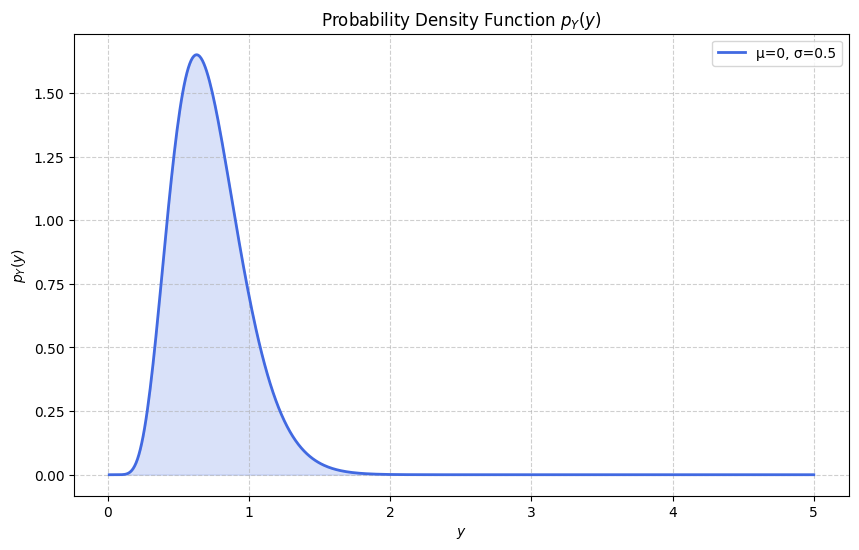

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def p_y(y, mu, sigma):
    """
    Implementation of the PDF from the image.
    Note: y must be > 0 because of the ln(e^y - 1) term.
    """
    term1 = 1 / (sigma * np.sqrt(2 * np.pi))
    exponent = -((np.log(np.exp(y) - 1) - mu)**2) / (2 * sigma**2)
    jacobian = np.exp(y) / (np.exp(y) - 1)
    
    return term1 * np.exp(exponent) * jacobian

# Parameters
mu = 0       # Mean of the underlying normal distribution
sigma = 0.5  # Standard deviation of the underlying normal distribution

# Generate y values (must be > 0)
y_values = np.linspace(0.01, 5, 500)
pdf_values = p_y(y_values, mu, sigma)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(y_values, pdf_values, label=f'μ={mu}, σ={sigma}', color='royalblue', lw=2)
plt.fill_between(y_values, pdf_values, color='royalblue', alpha=0.2)

plt.title('Probability Density Function $p_Y(y)$')
plt.xlabel('$y$')
plt.ylabel('$p_Y(y)$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

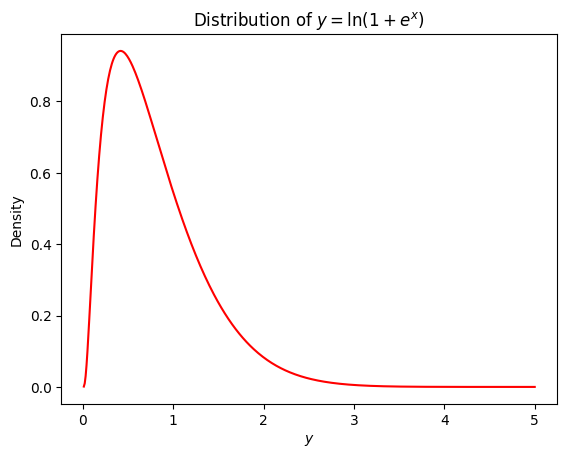

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def softplus_pdf(y, mu, sigma):
    # This is the exact formula from your image
    # Note: we use log1p and exp(-y) for better numerical stability at high y
    term1 = 1 / (sigma * np.sqrt(2 * np.pi))
    
    # ln(e^y - 1) is equivalent to y + ln(1 - e^-y)
    log_inner = y + np.log(1 - np.exp(-y))
    exponent = -((log_inner - mu)**2) / (2 * sigma**2)
    
    # Jacobian: e^y / (e^y - 1) is equivalent to 1 / (1 - e^-y)
    jacobian = 1 / (1 - np.exp(-y))
    
    return term1 * np.exp(exponent) * jacobian

# Parameters
mu, sigma = 0, 1
y_vals = np.linspace(0.01, 5, 500)
pdf_vals = softplus_pdf(y_vals, mu, sigma)

# Plotting
plt.plot(y_vals, pdf_vals, label='Theoretical PDF', color='red')
plt.title(r'Distribution of $y = \ln(1 + e^x)$')
plt.xlabel('$y$')
plt.ylabel('Density')
plt.show()

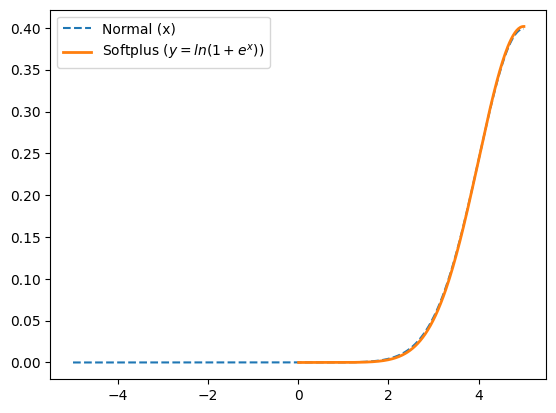

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def normal_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

def softplus_pdf(y, mu, sigma):
    """PDF from your image: p_Y(y) for y = ln(1 + e^x)"""
    y = np.atleast_1d(y)
    pdf = np.zeros_like(y)
    mask = y > 0
    # Numerically stable version of ln(e^y - 1) and e^y/(e^y - 1)
    log_inner = y[mask] + np.log(1 - np.exp(-y[mask]))
    jacobian = 1 / (1 - np.exp(-y[mask]))
    exponent = -0.5 * ((log_inner - mu) / sigma)**2
    pdf[mask] = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(exponent) * jacobian
    return pdf

mu, sigma = 5, 1
x_grid = np.linspace(-5, 5, 500)
y_grid = np.log(1 + np.e**x_grid)
# z_grid = 
plt.plot(x_grid, normal_pdf(x_grid, mu, sigma), '--', label='Normal (x)')
plt.plot(y_grid, softplus_pdf(y_grid, mu, sigma), label='Softplus ($y = ln(1 + e^x)$)', lw=2)
plt.legend()
plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_24276/505356405.py:15: SyntaxWarning: invalid escape sequence '\l'
  plt.hist(y_softplus, bins=200, range=(0, 6), density=True, alpha=0.5, label='Softplus ($\ln(1+e^X)$)')


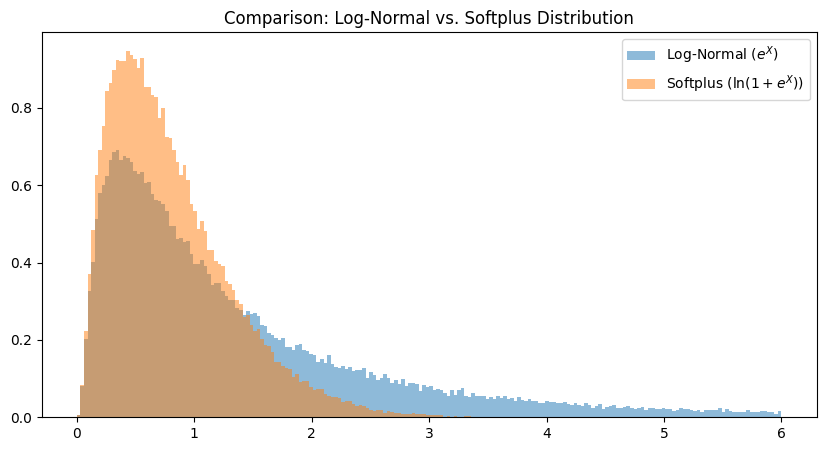

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
mu, sigma = 0, 1
x = np.random.normal(mu, sigma, 100000)

# Transformations
y_lognormal = np.exp(x)
y_softplus = np.log(1 + np.exp(x))

# Plotting
plt.figure(figsize=(10, 5))
plt.hist(y_lognormal, bins=200, range=(0, 6), density=True, alpha=0.5, label='Log-Normal ($e^X$)')
plt.hist(y_softplus, bins=200, range=(0, 6), density=True, alpha=0.5, label='Softplus ($\ln(1+e^X)$)')
plt.title("Comparison: Log-Normal vs. Softplus Distribution")
plt.legend()
plt.show()